In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import gzip

sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from layers import Conv2D, MaxPooling2D, Flatten, FullyConnected, ReLU, Softmax, Dropout, BatchNormalization
from losses import CrossEntropyLoss
from optimizers import Adam
from network import NeuralNetwork
from trainer import Trainer
from utils import one_hot, normalize, train_val_test_split
from augmentation import ImageAugmentation

## Load Fashion-MNIST Dataset


In [2]:
def load_fashion_mnist(path, kind='train'):
    """
    Load Fashion-MNIST data from IDX format.
    
    Args:
        path: Path to data directory
        kind: 'train' or 't10k' for test set
    """
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')
    
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)
    
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 784)
    
    return images, labels

# Load data
data_path = '../data/fashion_mnist/'
X_train_raw, y_train_raw = load_fashion_mnist(data_path, kind='train')
X_test_raw, y_test_raw = load_fashion_mnist(data_path, kind='t10k')

# Combine for splitting
X_all = np.vstack([X_train_raw, X_test_raw]).astype(np.float32)
y_all = np.hstack([y_train_raw, y_test_raw])

print(f'Total samples: {X_all.shape[0]}')
print(f'Image shape: {X_all.shape[1]}')

Total samples: 70000
Image shape: 784


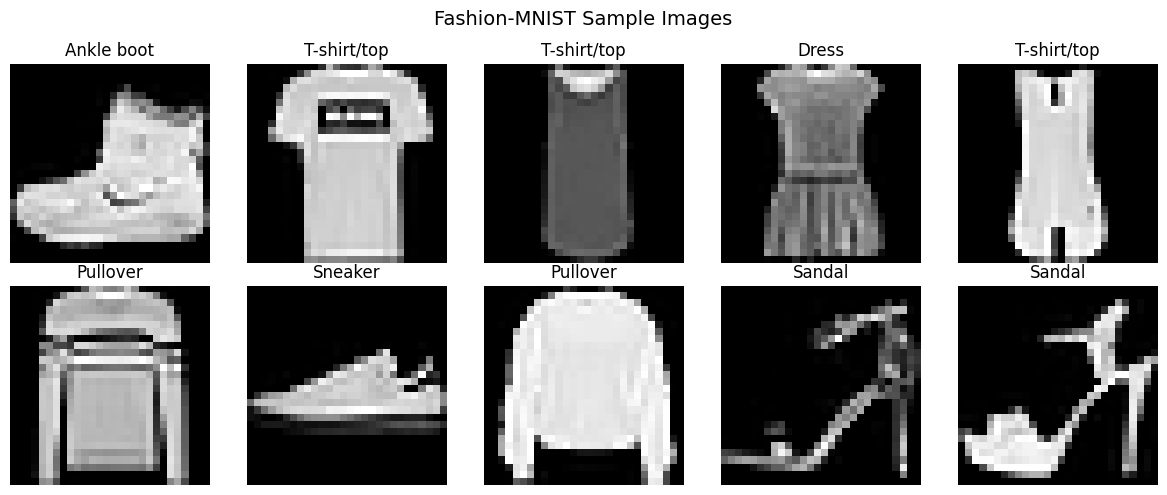

In [3]:
# Visualize sample images
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_all[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'{class_names[y_all[i]]}')
    axes[i].axis('off')

plt.suptitle('Fashion-MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## Preprocess Data

In [4]:
# Normalize
X_normalized = normalize(X_all)

# One-hot encode labels
y_oh = one_hot(y_all, num_classes=10)

# Split data
(X_train, y_train), (X_val, y_val), (X_test, y_test) = train_val_test_split(
    X_normalized, y_oh, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42
)

print(f'Training set: {X_train.shape}')
print(f'Validation set: {X_val.shape}')
print(f'Test set: {X_test.shape}')

Training set: (49000, 784)
Validation set: (10500, 784)
Test set: (10500, 784)


## Model 1: Deep Neural Network (DNN)


In [5]:
# Build DNN
dnn_layers = [
    FullyConnected(784, 256),
    ReLU(),
    Dropout(p=0.3),
    FullyConnected(256, 128),
    ReLU(),
    Dropout(p=0.3),
    FullyConnected(128, 64),
    ReLU(),
    Dropout(p=0.3),
    FullyConnected(64, 10),
    Softmax()
]

dnn = NeuralNetwork(dnn_layers)
dnn_optimizer = Adam(lr=0.001, weight_decay=0.0001)
dnn_loss = CrossEntropyLoss()
dnn_trainer = Trainer(dnn, dnn_optimizer, dnn_loss)


In [6]:
# Train DNN
print('Training DNN...')
dnn_train_losses, dnn_val_losses = dnn_trainer.train(
    X_train, y_train,
    X_val, y_val,
    epochs=10,
    batch_size=128,
    patience=5
)
print('DNN training complete!')

Training DNN...
Epoch 1, Batch 1/383, Batch loss: 2.8254
Epoch 1, Batch 2/383, Batch loss: 2.5365
Epoch 1, Batch 3/383, Batch loss: 2.2483
Epoch 1, Batch 4/383, Batch loss: 2.1648
Epoch 1, Batch 5/383, Batch loss: 2.0295
Epoch 1, Batch 6/383, Batch loss: 1.9646
Epoch 1, Batch 7/383, Batch loss: 1.8575
Epoch 1, Batch 8/383, Batch loss: 1.8229
Epoch 1, Batch 9/383, Batch loss: 1.8150
Epoch 1, Batch 10/383, Batch loss: 1.6422
Epoch 1, Batch 11/383, Batch loss: 1.5450
Epoch 1, Batch 12/383, Batch loss: 1.6082
Epoch 1, Batch 13/383, Batch loss: 1.6101
Epoch 1, Batch 14/383, Batch loss: 1.5500
Epoch 1, Batch 15/383, Batch loss: 1.4256
Epoch 1, Batch 16/383, Batch loss: 1.5067
Epoch 1, Batch 17/383, Batch loss: 1.5207
Epoch 1, Batch 18/383, Batch loss: 1.3760
Epoch 1, Batch 19/383, Batch loss: 1.3883
Epoch 1, Batch 20/383, Batch loss: 1.2859
Epoch 1, Batch 21/383, Batch loss: 1.2988
Epoch 1, Batch 22/383, Batch loss: 1.2101
Epoch 1, Batch 23/383, Batch loss: 1.3149
Epoch 1, Batch 24/383, Batc

In [7]:
# Evaluate DNN
dnn_out = dnn.forward(X_test)
dnn_preds = np.argmax(dnn_out, axis=1)
dnn_labels = np.argmax(y_test, axis=1)
dnn_accuracy = np.mean(dnn_preds == dnn_labels)

print(f'\nDNN Test Accuracy: {dnn_accuracy * 100:.2f}%')


DNN Test Accuracy: 80.94%


## Model 2: Convolutional Neural Network (CNN)

A CNN with convolutional layers to capture spatial features.

In [8]:
# Reshape data for CNN (batch, channels, height, width)
X_train_cnn = X_train.reshape(-1, 1, 28, 28)
X_val_cnn = X_val.reshape(-1, 1, 28, 28)
X_test_cnn = X_test.reshape(-1, 1, 28, 28)

print(f'CNN training set shape: {X_train_cnn.shape}')

CNN training set shape: (49000, 1, 28, 28)


In [9]:
# Build CNN
cnn_layers = [
    Conv2D(in_channels=1, num_filters=16, kernel_size=3),    # (1, 28, 28) -> (16, 26, 26)
    BatchNormalization(16),
    ReLU(),
    MaxPooling2D(pool_size=2),                                # (16, 26, 26) -> (16, 13, 13)
    Conv2D(in_channels=16, num_filters=32, kernel_size=3),   # (16, 13, 13) -> (32, 11, 11)
    BatchNormalization(32),
    ReLU(),
    MaxPooling2D(pool_size=2),                                # (32, 11, 11) -> (32, 5, 5)
    Flatten(),                                                # (32, 5, 5) -> 800
    FullyConnected(800, 128),
    ReLU(),
    Dropout(p=0.3),
    FullyConnected(128, 10),
    Softmax()
]

cnn = NeuralNetwork(cnn_layers)
cnn_optimizer = Adam(lr=0.001, weight_decay=0.0001)
cnn_loss = CrossEntropyLoss()
cnn_trainer = Trainer(cnn, cnn_optimizer, cnn_loss)



In [10]:
# Train CNN
print('Training CNN...')
cnn_train_losses, cnn_val_losses = cnn_trainer.train(
    X_train_cnn, y_train,
    X_val_cnn, y_val,
    epochs=10,
    batch_size=128,
    patience=5
)
print('CNN training complete!')

Training CNN...
Epoch 1, Batch 1/383, Batch loss: 3.7785
Epoch 1, Batch 2/383, Batch loss: 2.8104
Epoch 1, Batch 3/383, Batch loss: 2.6030
Epoch 1, Batch 4/383, Batch loss: 2.0442
Epoch 1, Batch 5/383, Batch loss: 2.1462
Epoch 1, Batch 6/383, Batch loss: 2.2402
Epoch 1, Batch 7/383, Batch loss: 1.7923
Epoch 1, Batch 8/383, Batch loss: 1.7535
Epoch 1, Batch 9/383, Batch loss: 1.6037
Epoch 1, Batch 10/383, Batch loss: 1.3983
Epoch 1, Batch 11/383, Batch loss: 1.2934
Epoch 1, Batch 12/383, Batch loss: 1.2051
Epoch 1, Batch 13/383, Batch loss: 1.1947
Epoch 1, Batch 14/383, Batch loss: 1.0232
Epoch 1, Batch 15/383, Batch loss: 1.1893
Epoch 1, Batch 16/383, Batch loss: 1.0993
Epoch 1, Batch 17/383, Batch loss: 1.0821
Epoch 1, Batch 18/383, Batch loss: 1.0164
Epoch 1, Batch 19/383, Batch loss: 1.2081
Epoch 1, Batch 20/383, Batch loss: 1.1045
Epoch 1, Batch 21/383, Batch loss: 1.1609
Epoch 1, Batch 22/383, Batch loss: 1.0801
Epoch 1, Batch 23/383, Batch loss: 0.9920
Epoch 1, Batch 24/383, Batc

In [11]:
# Evaluate CNN
cnn_out = cnn.forward(X_test_cnn)
cnn_preds = np.argmax(cnn_out, axis=1)
cnn_labels = np.argmax(y_test, axis=1)
cnn_accuracy = np.mean(cnn_preds == cnn_labels)

print(f'\nCNN Test Accuracy: {cnn_accuracy * 100:.2f}%')


CNN Test Accuracy: 87.63%


## Comparison: DNN vs CNN

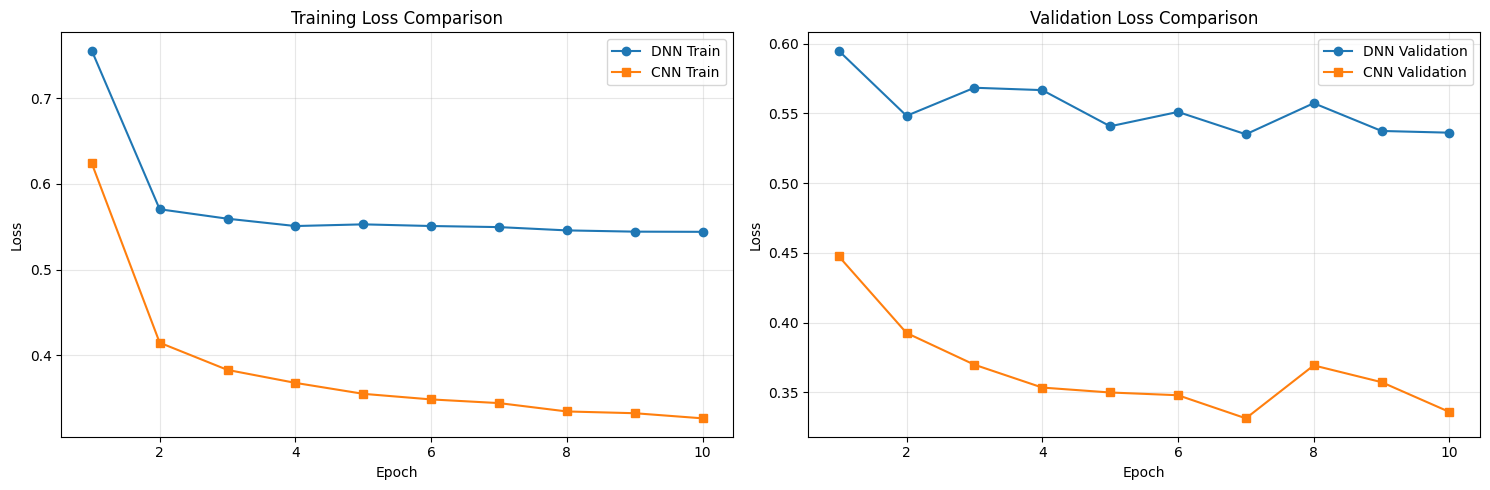

In [12]:
# Compare training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Create epoch numbers starting from 1
epochs = range(1, len(dnn_train_losses) + 1)

# Training loss comparison
axes[0].plot(epochs, dnn_train_losses, label='DNN Train', marker='o')
axes[0].plot(epochs, cnn_train_losses, label='CNN Train', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss comparison
axes[1].plot(epochs, dnn_val_losses, label='DNN Validation', marker='o')
axes[1].plot(epochs, cnn_val_losses, label='CNN Validation', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

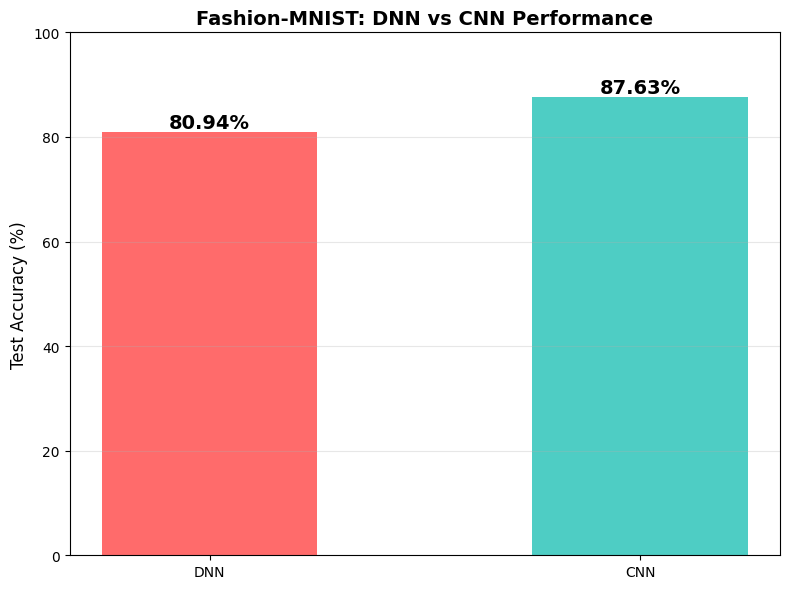


FINAL RESULTS:
DNN Test Accuracy: 80.94%
CNN Test Accuracy: 87.63%
Improvement: 6.69 percentage points
Relative improvement: 8.26%


In [13]:
# Accuracy comparison bar chart
models = ['DNN', 'CNN']
accuracies = [dnn_accuracy * 100, cnn_accuracy * 100]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4'], width=0.5)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Fashion-MNIST: DNN vs CNN Performance', fontsize=14, fontweight='bold')
plt.ylim([0, 100])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n{"="*50}')
print(f'FINAL RESULTS:')
print(f'{"="*50}')
print(f'DNN Test Accuracy: {dnn_accuracy * 100:.2f}%')
print(f'CNN Test Accuracy: {cnn_accuracy * 100:.2f}%')
print(f'Improvement: {(cnn_accuracy - dnn_accuracy) * 100:.2f} percentage points')
print(f'Relative improvement: {((cnn_accuracy / dnn_accuracy) - 1) * 100:.2f}%')
print(f'{"="*50}')

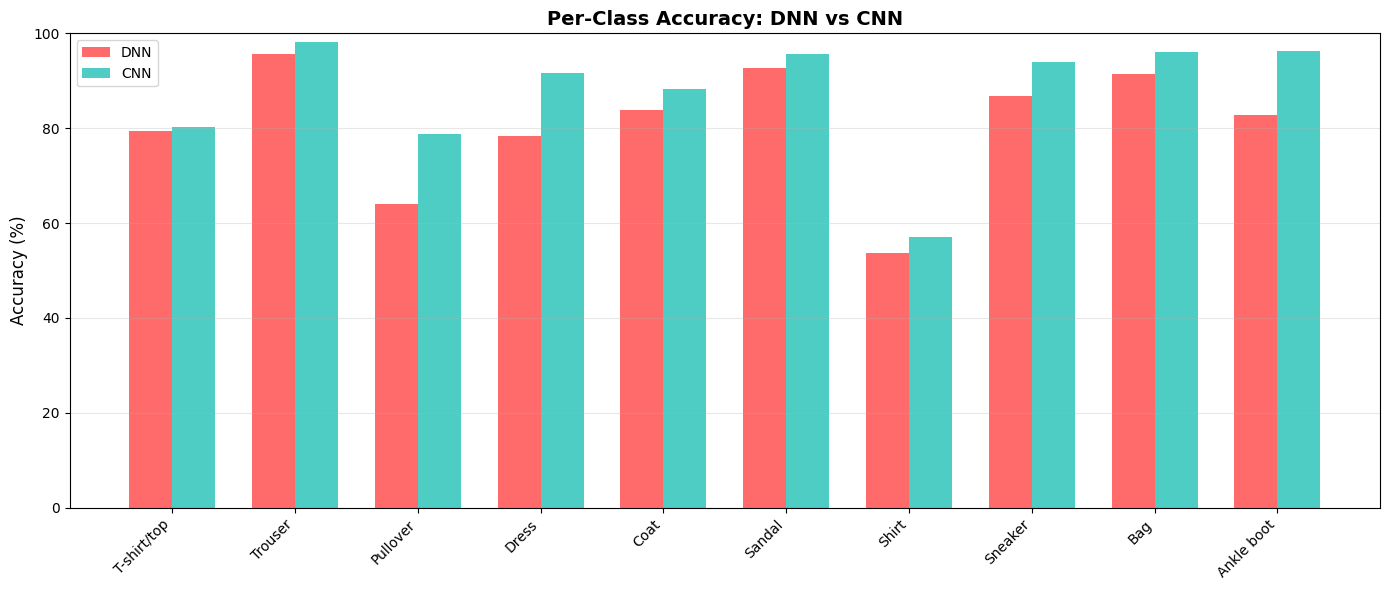


Per-class accuracy:
Class           DNN        CNN        Improvement
--------------------------------------------------
T-shirt/top      79.41%    80.27%    +0.85%
Trouser          95.74%    98.20%    +2.46%
Pullover         64.07%    78.87%   +14.80%
Dress            78.33%    91.67%   +13.33%
Coat             83.90%    88.29%    +4.39%
Sandal           92.70%    95.71%    +3.01%
Shirt            53.77%    57.12%    +3.35%
Sneaker          86.69%    94.05%    +7.37%
Bag              91.40%    96.12%    +4.71%
Ankle boot       82.79%    96.32%   +13.53%


In [14]:
# Per-class accuracy comparison
dnn_class_correct = np.zeros(10)
cnn_class_correct = np.zeros(10)
class_total = np.zeros(10)

for i in range(len(dnn_labels)):
    label = dnn_labels[i]
    class_total[label] += 1
    if dnn_preds[i] == label:
        dnn_class_correct[label] += 1
    if cnn_preds[i] == label:
        cnn_class_correct[label] += 1

dnn_class_acc = (dnn_class_correct / class_total) * 100
cnn_class_acc = (cnn_class_correct / class_total) * 100

# Plot per-class accuracy
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, dnn_class_acc, width, label='DNN', color='#FF6B6B')
bars2 = ax.bar(x + width/2, cnn_class_acc, width, label='CNN', color='#4ECDC4')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy: DNN vs CNN', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

print('\nPer-class accuracy:')
print(f'{"Class":<15} {"DNN":<10} {"CNN":<10} {"Improvement"}')
print('-' * 50)
for i, name in enumerate(class_names):
    improvement = cnn_class_acc[i] - dnn_class_acc[i]
    print(f'{name:<15} {dnn_class_acc[i]:>6.2f}%   {cnn_class_acc[i]:>6.2f}%   {improvement:>+6.2f}%')

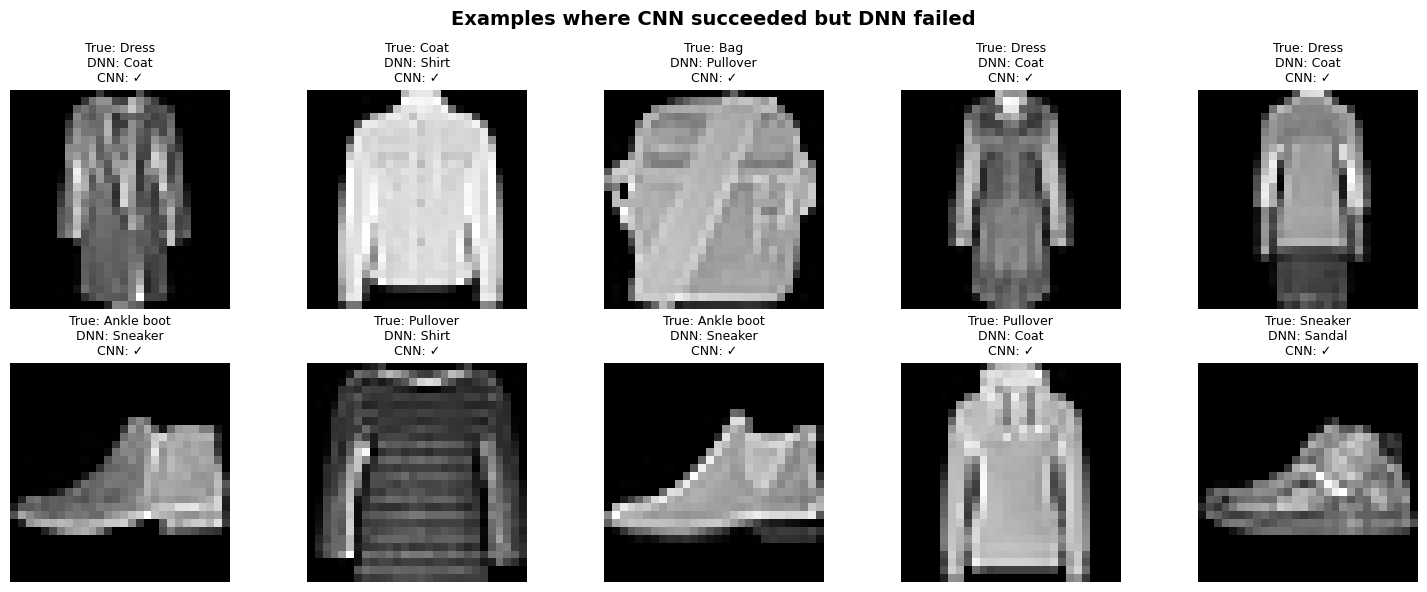

In [15]:
# Show examples where CNN succeeded but DNN failed
cnn_correct_dnn_wrong = (cnn_preds == cnn_labels) & (dnn_preds != dnn_labels)
indices = np.where(cnn_correct_dnn_wrong)[0][:10]

if len(indices) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    for i, idx in enumerate(indices):
        axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
        true_label = class_names[cnn_labels[idx]]
        dnn_pred = class_names[dnn_preds[idx]]
        axes[i].set_title(f'True: {true_label}\nDNN: {dnn_pred}\nCNN: ✓', fontsize=9)
        axes[i].axis('off')
    
    plt.suptitle('Examples where CNN succeeded but DNN failed', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Visualize CNN Feature Maps


In [16]:
# Helper function to extract feature maps from intermediate layers
def get_feature_maps(network, x, layer_indices):
    """
    Extract feature maps from specified layers.
    
    Args:
        network: Neural network
        x: Input image (single sample)
        layer_indices: List of layer indices to extract from
        
    Returns:
        Dictionary mapping layer index to feature maps
    """
    feature_maps = {}
    activation = x
    
    for i, layer in enumerate(network.layers):
        activation = layer.forward(activation)
        if i in layer_indices:
            feature_maps[i] = activation
    
    return feature_maps

# Select a test image to visualize
sample_idx = 0
sample_image = X_test_cnn[sample_idx:sample_idx+1]
true_label = class_names[cnn_labels[sample_idx]]
predicted_label = class_names[cnn_preds[sample_idx]]

# Get feature maps from the two convolutional layers
# Layer 0: First Conv2D, Layer 5: Second Conv2D
conv_layer_indices = [0, 5]
feature_maps = get_feature_maps(cnn, sample_image, conv_layer_indices)

print(f"Visualizing feature maps for image: {true_label}")
print(f"CNN prediction: {predicted_label}")
print(f"First Conv2D output shape: {feature_maps[0].shape}")
print(f"Second Conv2D output shape: {feature_maps[5].shape}")

Visualizing feature maps for image: Pullover
CNN prediction: Pullover
First Conv2D output shape: (1, 16, 26, 26)
Second Conv2D output shape: (1, 32, 11, 11)


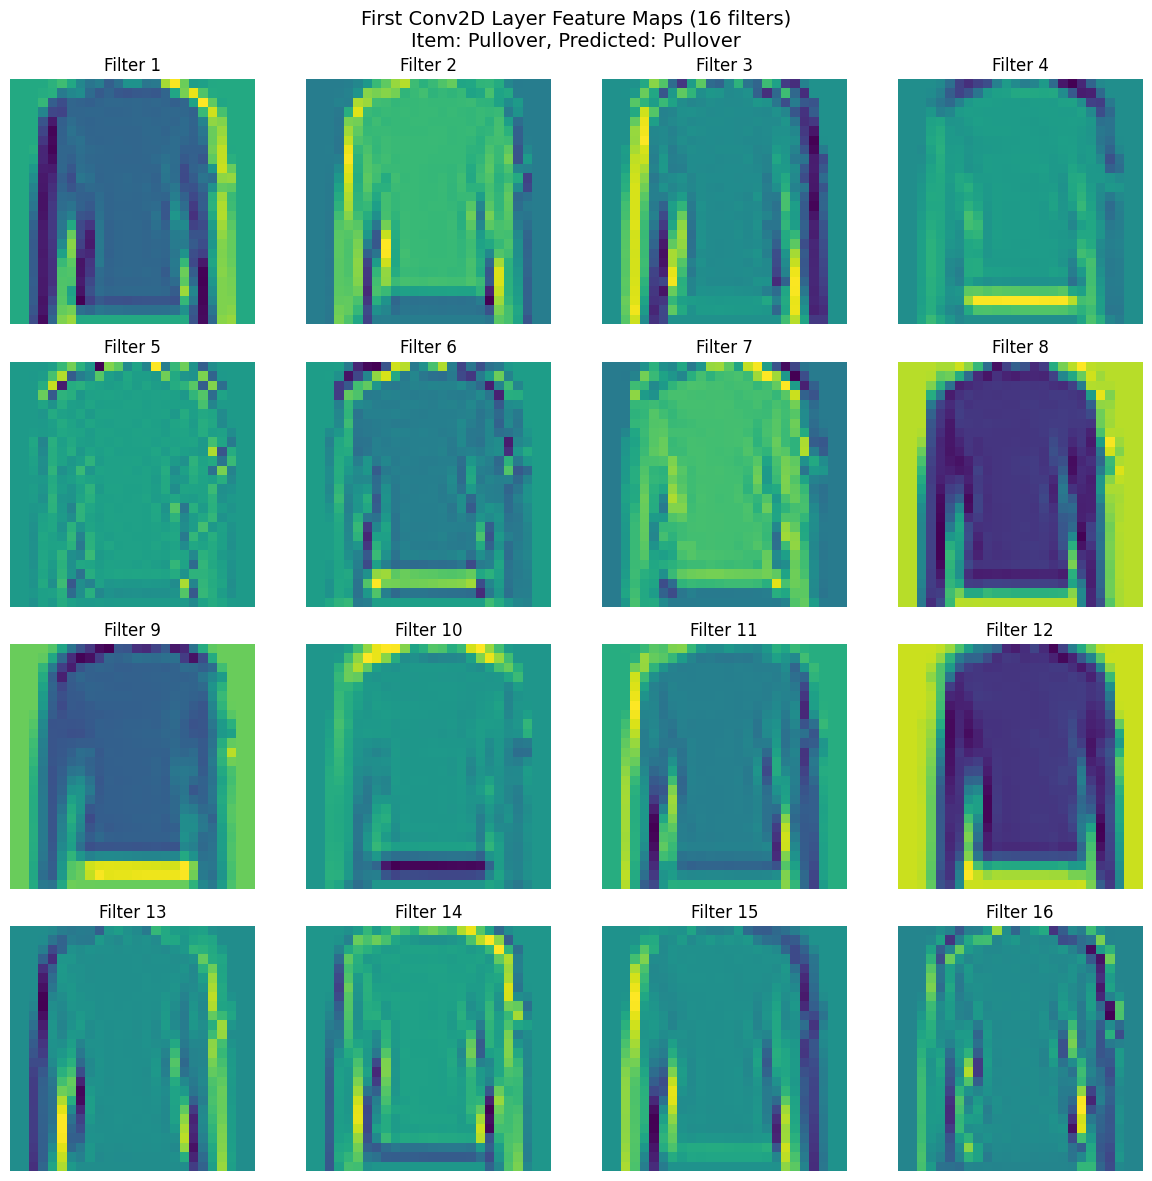

In [17]:
# Visualize first convolutional layer feature maps (16 filters)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.ravel()

fig.suptitle(f'First Conv2D Layer Feature Maps (16 filters)\nItem: {true_label}, Predicted: {predicted_label}', fontsize=14)

conv1_output = feature_maps[0][0]  # Remove batch dimension

for i in range(16):
    axes[i].imshow(conv1_output[i], cmap='viridis')
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

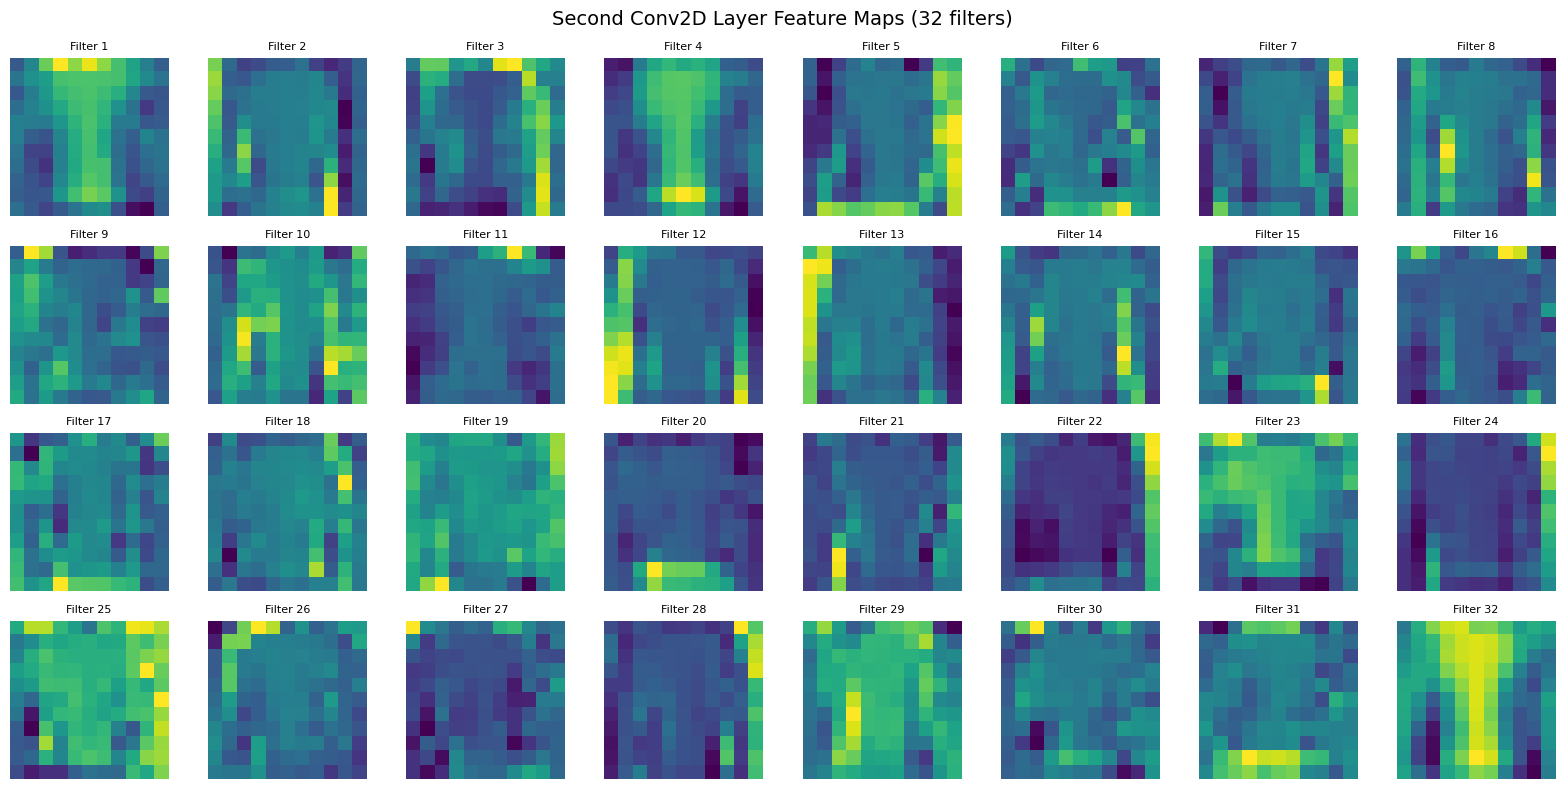

In [18]:
# Visualize second convolutional layer feature maps (32 filters)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.ravel()

fig.suptitle(f'Second Conv2D Layer Feature Maps (32 filters)', fontsize=14)

conv2_output = feature_maps[5][0]  # Remove batch dimension

for i in range(32):
    axes[i].imshow(conv2_output[i], cmap='viridis')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

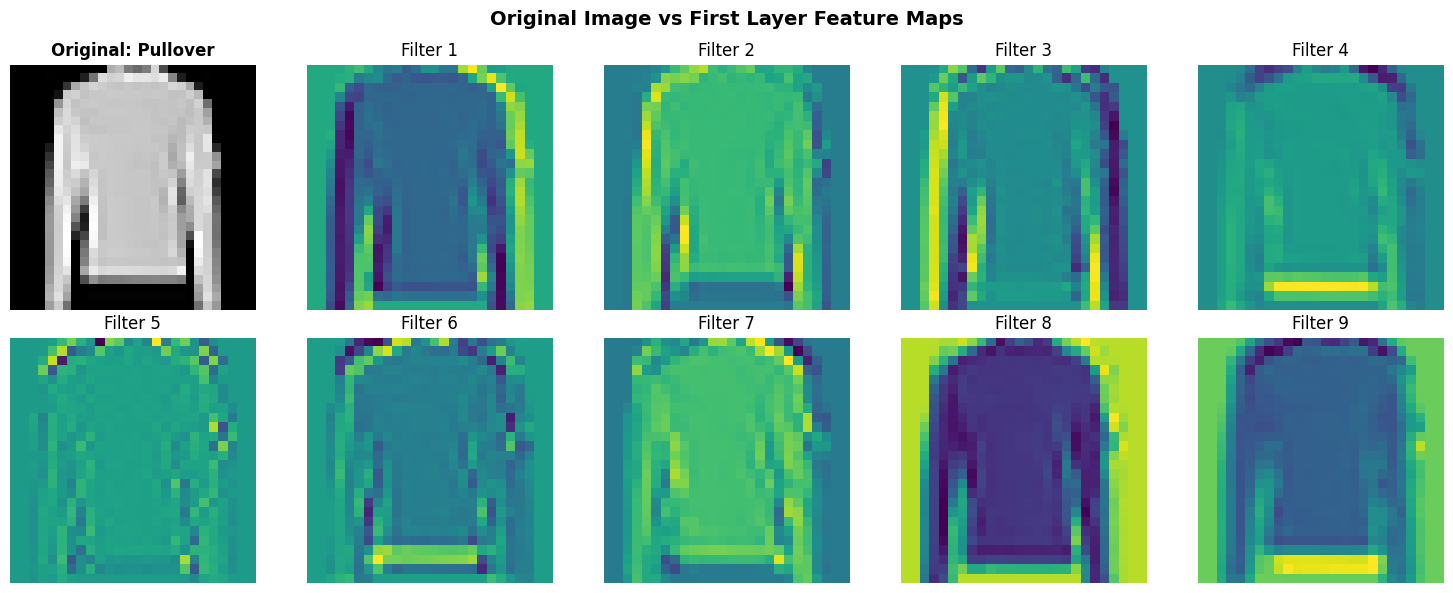

In [19]:
# Compare original image with feature maps from first layer
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Original image
axes[0, 0].imshow(sample_image[0, 0], cmap='gray')
axes[0, 0].set_title(f'Original: {true_label}', fontweight='bold')
axes[0, 0].axis('off')

# Show 9 feature maps from first conv layer
conv1_output = feature_maps[0][0]
for i in range(9):
    row = (i + 1) // 5
    col = (i + 1) % 5
    axes[row, col].imshow(conv1_output[i], cmap='viridis')
    axes[row, col].set_title(f'Filter {i+1}')
    axes[row, col].axis('off')

plt.suptitle('Original Image vs First Layer Feature Maps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Experiment: Data Augmentation


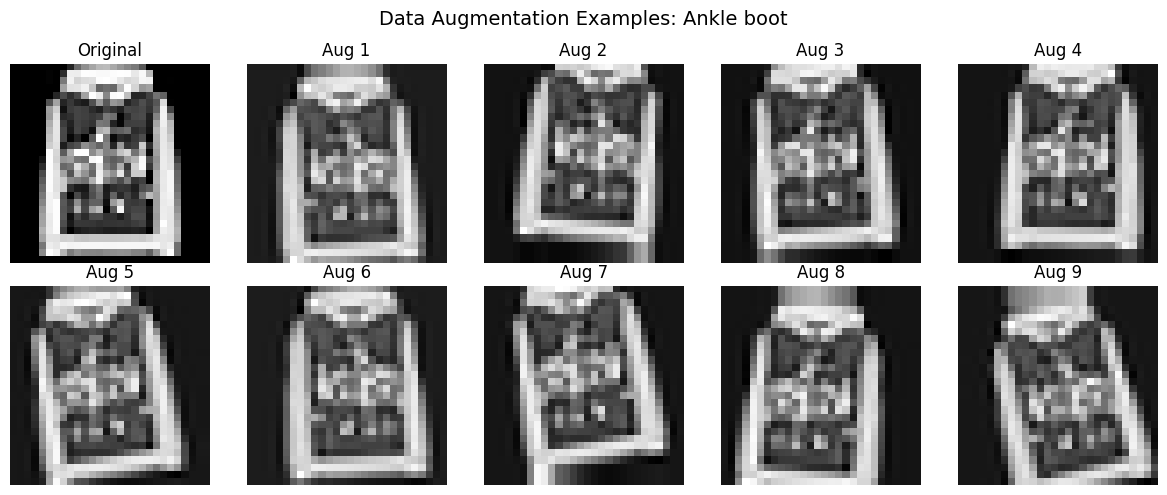

In [20]:
# Create data augmenter
augmenter = ImageAugmentation(
    rotation_range=15,
    shift_range=0.1,
    horizontal_flip=True
)

# Visualize augmented samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

sample_idx = 0
sample_image_4d = X_train_cnn[sample_idx:sample_idx+1]

# Original image
axes[0, 0].imshow(sample_image_4d[0, 0], cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Generate 9 augmented versions
for i in range(9):
    row = (i + 1) // 5
    col = (i + 1) % 5
    
    augmented = augmenter.augment_batch(sample_image_4d)
    axes[row, col].imshow(augmented[0, 0], cmap='gray')
    axes[row, col].set_title(f'Aug {i+1}')
    axes[row, col].axis('off')

plt.suptitle(f'Data Augmentation Examples: {class_names[y_train_raw[sample_idx]]}', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Build CNN with same architecture for augmentation experiment
cnn_aug_layers = [
    Conv2D(in_channels=1, num_filters=16, kernel_size=3),
    BatchNormalization(16),
    ReLU(),
    MaxPooling2D(pool_size=2),
    Conv2D(in_channels=16, num_filters=32, kernel_size=3),
    BatchNormalization(32),
    ReLU(),
    MaxPooling2D(pool_size=2),
    Flatten(),
    FullyConnected(800, 128),
    ReLU(),
    Dropout(p=0.3),
    FullyConnected(128, 10),
    Softmax()
]

cnn_aug = NeuralNetwork(cnn_aug_layers)
cnn_aug_optimizer = Adam(lr=0.001, weight_decay=0.0001)
cnn_aug_loss = CrossEntropyLoss()
cnn_aug_trainer = Trainer(cnn_aug, cnn_aug_optimizer, cnn_aug_loss)


In [22]:
# Train with augmentation
print('Training CNN with augmentation...')
cnn_aug_train_losses, cnn_aug_val_losses = cnn_aug_trainer.train(
    X_train_cnn, y_train,
    X_val_cnn, y_val,
    epochs=10,
    batch_size=128,
    patience=5,
    augmenter=augmenter
)
print('Training complete!')

Training CNN with augmentation...
Epoch 1, Batch 1/383, Batch loss: 3.2477
Epoch 1, Batch 2/383, Batch loss: 2.7682
Epoch 1, Batch 3/383, Batch loss: 2.1073
Epoch 1, Batch 4/383, Batch loss: 1.9903
Epoch 1, Batch 5/383, Batch loss: 2.0197
Epoch 1, Batch 6/383, Batch loss: 1.9273
Epoch 1, Batch 7/383, Batch loss: 1.8042
Epoch 1, Batch 8/383, Batch loss: 1.6391
Epoch 1, Batch 9/383, Batch loss: 1.4351
Epoch 1, Batch 10/383, Batch loss: 1.5884
Epoch 1, Batch 11/383, Batch loss: 1.5088
Epoch 1, Batch 12/383, Batch loss: 1.3220
Epoch 1, Batch 13/383, Batch loss: 1.4523
Epoch 1, Batch 14/383, Batch loss: 1.2707
Epoch 1, Batch 15/383, Batch loss: 1.4499
Epoch 1, Batch 16/383, Batch loss: 1.3213
Epoch 1, Batch 17/383, Batch loss: 1.3893
Epoch 1, Batch 18/383, Batch loss: 1.1786
Epoch 1, Batch 19/383, Batch loss: 1.2979
Epoch 1, Batch 20/383, Batch loss: 1.2473
Epoch 1, Batch 21/383, Batch loss: 1.1612
Epoch 1, Batch 22/383, Batch loss: 1.2202
Epoch 1, Batch 23/383, Batch loss: 1.1770
Epoch 1, 

In [23]:
# Evaluate CNN with augmentation
cnn_aug_out = cnn_aug.forward(X_test_cnn)
cnn_aug_preds = np.argmax(cnn_aug_out, axis=1)
cnn_aug_accuracy = np.mean(cnn_aug_preds == cnn_labels)

print(f'\nCNN (baseline) test accuracy: {cnn_accuracy * 100:.2f}%')
print(f'CNN (with augmentation) test accuracy: {cnn_aug_accuracy * 100:.2f}%')
print(f'Difference: {(cnn_aug_accuracy - cnn_accuracy) * 100:.2f} percentage points')


CNN (baseline) test accuracy: 87.63%
CNN (with augmentation) test accuracy: 85.08%
Difference: -2.55 percentage points


CNN with augmentation - same architecture as baseline CNN


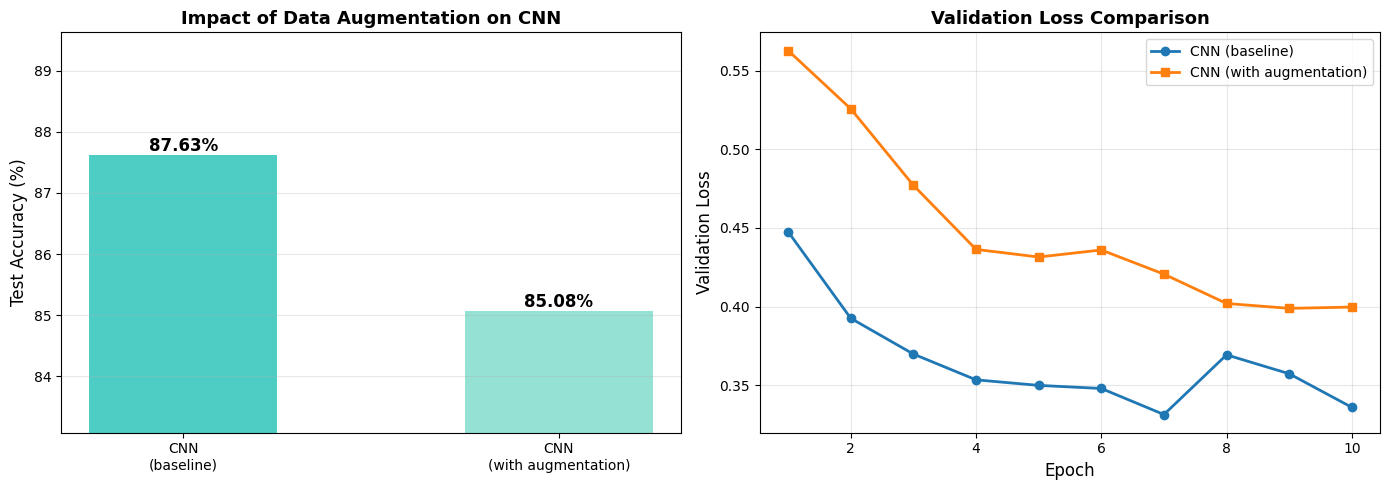


AUGMENTATION EXPERIMENT RESULTS:
Baseline CNN:            87.63%
CNN with augmentation:   85.08%
✗ Augmentation decreased accuracy by 2.55%


In [24]:
# Compare results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models = ['CNN\n(baseline)', 'CNN\n(with augmentation)']
accuracies = [cnn_accuracy * 100, cnn_aug_accuracy * 100]

bars = ax1.bar(models, accuracies, color=['#4ECDC4', '#95E1D3'], width=0.5)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Impact of Data Augmentation on CNN', fontsize=13, fontweight='bold')
ax1.set_ylim([min(accuracies) - 2, max(accuracies) + 2])
ax1.grid(True, alpha=0.3, axis='y')
print("CNN with augmentation - same architecture as baseline CNN")

# Add value labels
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Training curves
epochs_baseline = range(1, len(cnn_train_losses) + 1)
epochs_aug = range(1, len(cnn_aug_train_losses) + 1)

ax2.plot(epochs_baseline, cnn_val_losses, 'o-', label='CNN (baseline)', linewidth=2)
ax2.plot(epochs_aug, cnn_aug_val_losses, 's-', label='CNN (with augmentation)', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Loss', fontsize=12)
ax2.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n{"="*60}')
print(f'AUGMENTATION EXPERIMENT RESULTS:')
print(f'{"="*60}')
print(f'Baseline CNN:            {cnn_accuracy * 100:.2f}%')
print(f'CNN with augmentation:   {cnn_aug_accuracy * 100:.2f}%')
if cnn_aug_accuracy > cnn_accuracy:
    print(f'✓ Augmentation improved accuracy by {(cnn_aug_accuracy - cnn_accuracy) * 100:.2f}%')
else:
    print(f'✗ Augmentation decreased accuracy by {(cnn_accuracy - cnn_aug_accuracy) * 100:.2f}%')
print(f'{"="*60}')